# Quick MEM — 1D Mechanical Earth Model Workflow

End-to-end demo of **GeomechPy** following the standard MEM sequence:

1. Data input (pandas)
2. Overburden stress
3. Lithology (toolbox)
4. Pore pressure
5. Dynamic elastic properties
6. Static elastic properties
7. Rock strength
8. Horizontal stresses + stress-tensor rotation
9. Wellbore stability (breakout / breakdown)

Synthetic log data is generated so the notebook runs without external files.


## 0. Setup & imports


In [1]:
import sys
from pathlib import Path

# repo root = two levels up from this notebook (example/Project/)
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "Project":
    REPO_ROOT = REPO_ROOT.parent.parent
elif REPO_ROOT.name == "example":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "example"))  # lithology in example/toolbox.py

import numpy as np
import pandas as pd

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import glob
import shutil
import plotly.io as pio


def _configure_plotly_renderer():
    """Embed a static PNG next to the interactive figure so plots show in
    every viewer (GitHub, nbviewer, JupyterLab, VS Code). Falls back to the
    interactive-only renderer when no Chrome/Chromium engine is available for
    static image export."""
    candidates = [os.environ.get("BROWSER_PATH")]
    candidates += [shutil.which(name) for name in
                   ("google-chrome", "google-chrome-stable", "chromium",
                    "chromium-browser", "chrome")]
    candidates += sorted(glob.glob("/opt/pw-browsers/chromium-*/chrome-linux/chrome"))
    for path in candidates:
        if path and os.path.exists(path):
            os.environ["BROWSER_PATH"] = path
            break
    try:
        import plotly.graph_objects as _go
        _go.Figure().to_image(format="png", width=200, height=200)
        pio.renderers.default = "plotly_mimetype+png"
    except Exception:
        pio.renderers.default = "plotly_mimetype+notebook_connected"


_configure_plotly_renderer()

from geomechpy.overburden_stress import OverburdenStressCalculation
from geomechpy.pore_pressure import PorePressureCalculation
from geomechpy.elastic_properties import ElasticPropertiesConverter
from geomechpy.static_elastic_properties import StaticElasticPropertiesConverter
from geomechpy.rock_strength import RockStrengthPropertiesConverter
from geomechpy.stress_calculations import HorizontalStressesCalculation
from geomechpy.wellbore_stability import WellboreStabilityCalculation
from geomechpy.toolbox import rotate_stress_to_shmax, rotate_nev_to_toh
from toolbox import determine_lithology_array  # example/toolbox.py

print("Imports OK — repo root:", REPO_ROOT)
print("Plotly renderer:", pio.renderers.default)

def qc_log_plot(tracks, title, height=560, width=1150):
    """Composite depth-track QC figure.

    tracks: list of (subplot_title, [(x_series, trace_name, color, dash), ...])
    Depth increases downward; all tracks share the TVD axis.
    """
    fig = make_subplots(
        rows=1, cols=len(tracks), shared_yaxes=True, horizontal_spacing=0.022,
        subplot_titles=[t[0] for t in tracks],
    )
    for col, (_, curves) in enumerate(tracks, start=1):
        for x_series, name, color, dash in curves:
            fig.add_trace(
                go.Scatter(x=x_series, y=df["TVD"], mode="lines", name=name,
                           line=dict(color=color, dash=dash)),
                row=1, col=col,
            )
    fig.update_yaxes(autorange="reversed", title_text="TVD (ft)", row=1, col=1)
    fig.update_layout(
        height=height, width=width, template="plotly_white", title=title,
        legend=dict(orientation="h", yanchor="bottom", y=1.04, xanchor="left", x=0),
        margin=dict(t=110),
    )
    return fig


Imports OK — repo root: /workspace/0xsmolrun/geomechpy_smolrun
Plotly renderer: plotly_mimetype+png


## 1. Data input

Synthetic onshore well log (TVD from 5 000 – 8 000 ft).
Columns mimic typical LAS curves used in a 1-D MEM.


,TVD,GR,RHOB,DTCO,DTSH,NPHI,COAL,LIME
0,5000.0,42.483571,2.346287,92.805589,161.447417,0.167997,False,False
1,5050.0,47.625146,2.329873,86.946298,158.929612,0.175655,False,False
2,5100.0,59.507908,2.330076,90.673714,161.342001,0.173251,False,False
3,5150.0,71.126559,2.372251,93.630911,160.219713,0.170467,False,False
4,5200.0,68.555026,2.385125,87.018927,158.181513,0.193655,False,False


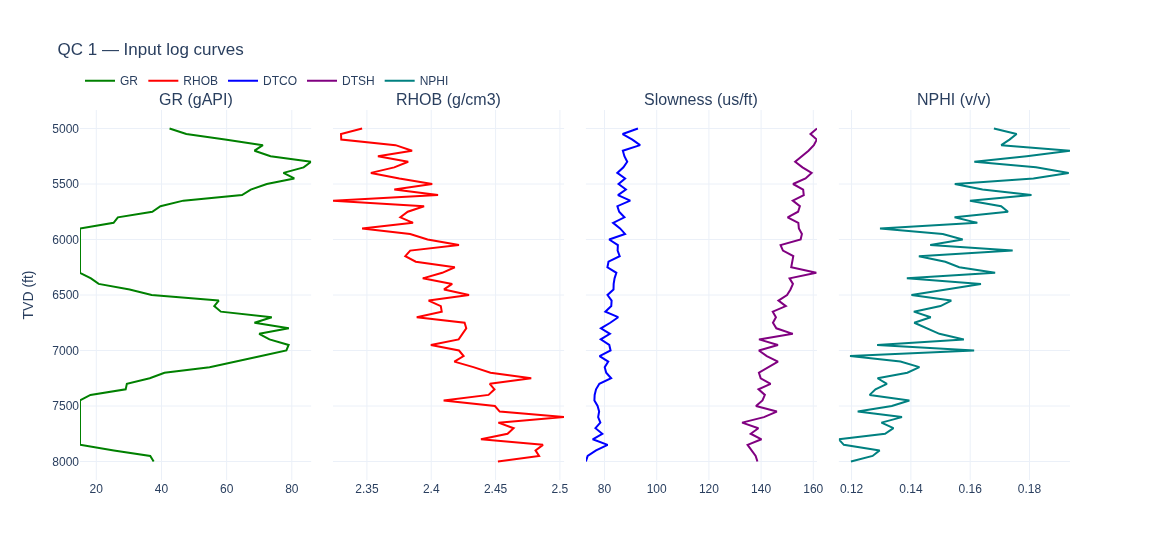

In [2]:
np.random.seed(42)
n = 61
tvd = np.linspace(5000.0, 8000.0, n)  # ft

# Synthetic curves with mild depth trends + noise
gr = 40 + 40 * np.sin(np.linspace(0, 4 * np.pi, n)) + np.random.normal(0, 5, n)  # gAPI
gr = np.clip(gr, 15, 140)

rhob = 2.35 + 0.00004 * (tvd - 5000) + np.random.normal(0, 0.02, n)  # g/cm3
dtco = 90 - 0.005 * (tvd - 5000) + np.random.normal(0, 2, n)       # us/ft
dtsh = 160 - 0.008 * (tvd - 5000) + np.random.normal(0, 3, n)      # us/ft
nphi = 0.18 - 0.00002 * (tvd - 5000) + np.random.normal(0, 0.01, n) # fraction
nphi = np.clip(nphi, 0.05, 0.30)

# Optional coal / limestone flags (mostly False)
coal_flag = [False] * n
limestone_flag = [False] * n
coal_flag[20] = True
limestone_flag[45] = True

df = pd.DataFrame({
    "TVD": tvd,
    "GR": gr,
    "RHOB": rhob,
    "DTCO": dtco,
    "DTSH": dtsh,
    "NPHI": nphi,
    "COAL": coal_flag,
    "LIME": limestone_flag,
})
display(df.head())

# QC — raw input log curves
qc_log_plot(
    [
        ("GR (gAPI)", [(df["GR"], "GR", "green", None)]),
        ("RHOB (g/cm3)", [(df["RHOB"], "RHOB", "red", None)]),
        ("Slowness (us/ft)", [(df["DTCO"], "DTCO", "blue", None),
                              (df["DTSH"], "DTSH", "purple", None)]),
        ("NPHI (v/v)", [(df["NPHI"], "NPHI", "teal", None)]),
    ],
    "QC 1 — Input log curves",
).show()

## 2. Overburden stress (onshore)


,TVD,SV,SV_GRAD
0,5000.0,5218.512,1.043702
1,5050.0,5271.012,1.043765
2,5100.0,5323.512,1.043826
3,5150.0,5376.012,1.043886
4,5200.0,5428.512,1.043945


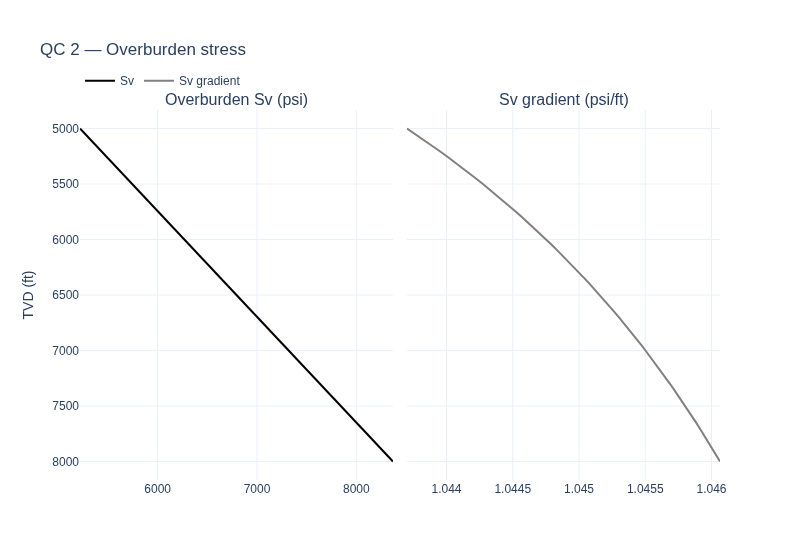

In [3]:
AIR_GAP = 30.0  # ft KB to ground
LITHOSTATIC_GRAD = 1.05  # psi/ft

df["SV"] = OverburdenStressCalculation.calculate_overburden_stress_onshore_array(
    tvd=df["TVD"].tolist(),
    lithostatic_gradient=LITHOSTATIC_GRAD,
    air_gap=AIR_GAP,
)
df["SV_GRAD"] = df["SV"] / df["TVD"]  # psi/ft, QC on the integrated gradient
display(df[["TVD", "SV", "SV_GRAD"]].head())

qc_log_plot(
    [
        ("Overburden Sv (psi)", [(df["SV"], "Sv", "black", None)]),
        ("Sv gradient (psi/ft)", [(df["SV_GRAD"], "Sv gradient", "grey", None)]),
    ],
    "QC 2 — Overburden stress",
    width=800,
).show()

## 3. Lithology (mechanical stratigraphy from GR)


LITH_NAME
Sand         52
Shale         7
Coal          1
Limestone     1
Name: count, dtype: int64

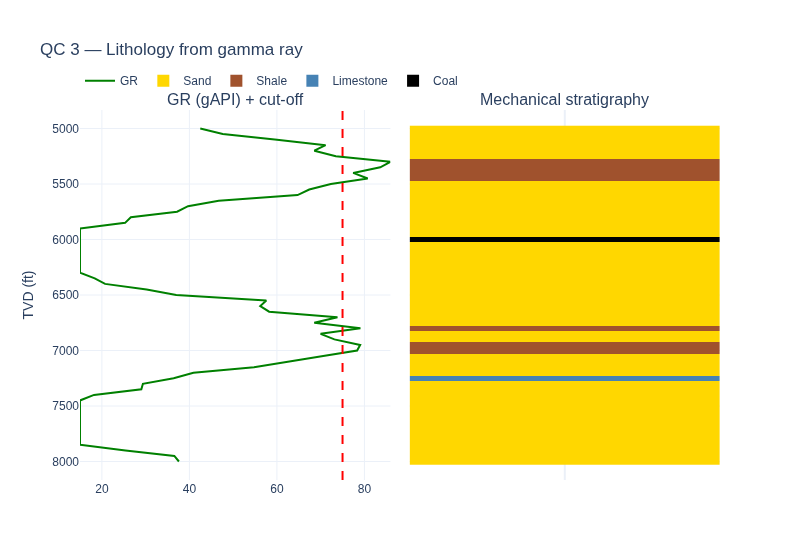

In [4]:
GR_THRESHOLD = 75.0

df["LITH"] = determine_lithology_array(
    gamma_ray=df["GR"].tolist(),
    gr_threshold=GR_THRESHOLD,
    coal_flag=df["COAL"].tolist(),
    limestone_flag=df["LIME"].tolist(),
)
# 0=Sand, 1=Shale, 2=Limestone, 6=Coal
LITH_NAMES = {0: "Sand", 1: "Shale", 2: "Limestone", 6: "Coal"}
LITH_COLORS = {0: "gold", 1: "sienna", 2: "steelblue", 6: "black"}
df["LITH_NAME"] = df["LITH"].map(LITH_NAMES)
display(df[["TVD", "GR", "LITH", "LITH_NAME"]].value_counts("LITH_NAME"))

# QC — GR against the shale cut-off, plus the resulting lithology column.
# The lithology track is drawn as a heatmap so the facies tile without gaps.
present = sorted(df["LITH"].unique())
index_of = {code_value: i for i, code_value in enumerate(present)}
z = [[index_of[v]] for v in df["LITH"]]

if len(present) > 1:
    bounds = [i / len(present) for i in range(len(present) + 1)]
    colorscale = []
    for i, code_value in enumerate(present):
        colorscale.append([bounds[i], LITH_COLORS[code_value]])
        colorscale.append([bounds[i + 1], LITH_COLORS[code_value]])
else:
    colorscale = [[0, LITH_COLORS[present[0]]], [1, LITH_COLORS[present[0]]]]

fig = make_subplots(rows=1, cols=2, shared_yaxes=True, horizontal_spacing=0.03,
                    subplot_titles=("GR (gAPI) + cut-off", "Mechanical stratigraphy"))
fig.add_trace(go.Scatter(x=df["GR"], y=df["TVD"], mode="lines",
                         line=dict(color="green"), name="GR"), row=1, col=1)
fig.add_vline(x=GR_THRESHOLD, line=dict(color="red", dash="dash"), row=1, col=1)

fig.add_trace(go.Heatmap(
    z=z, y=df["TVD"], x=[0], colorscale=colorscale,
    zmin=-0.5, zmax=len(present) - 0.5, showscale=False,
    text=[[df["LITH_NAME"].iloc[i]] for i in range(len(df))],
    hovertemplate="TVD %{y:.0f} ft<br>%{text}<extra></extra>",
), row=1, col=2)

# Legend proxies so the facies colours are named.
for code_value in present:
    fig.add_trace(go.Scatter(x=[None], y=[None], mode="markers",
                             marker=dict(size=12, color=LITH_COLORS[code_value],
                                         symbol="square"),
                             name=LITH_NAMES[code_value]), row=1, col=2)

fig.update_xaxes(showticklabels=False, row=1, col=2)
fig.update_yaxes(autorange="reversed", title_text="TVD (ft)", row=1, col=1)
fig.update_layout(height=560, width=800, template="plotly_white",
                  title="QC 3 — Lithology from gamma ray",
                  legend=dict(orientation="h", yanchor="bottom", y=1.04, xanchor="left", x=0),
                  margin=dict(t=110))
fig.show()

## 4. Pore pressure (onshore hydrostatic)


,TVD,PP,PP_GRAD
0,5000.0,2311.062,0.462212
1,5050.0,2334.312,0.462240
2,5100.0,2357.562,0.462267
3,5150.0,2380.812,0.462294
4,5200.0,2404.062,0.462320


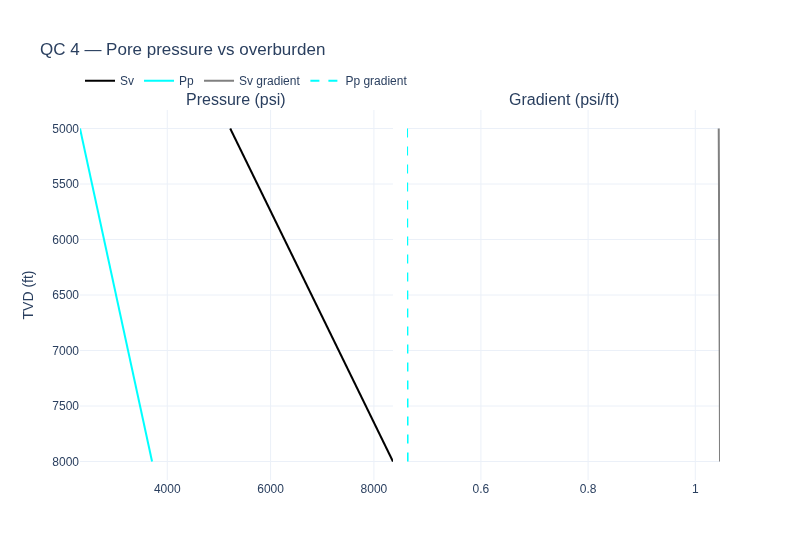

In [5]:
PP_GRAD = 0.465  # psi/ft

df["PP"] = PorePressureCalculation.calculate_pore_pressure_onshore_array(
    tvd=df["TVD"].tolist(),
    formation_pore_pressure_gradient=PP_GRAD,
    air_gap=AIR_GAP,
)
df["PP_GRAD"] = df["PP"] / df["TVD"]  # psi/ft
display(df[["TVD", "PP", "PP_GRAD"]].head())

qc_log_plot(
    [
        ("Pressure (psi)", [(df["SV"], "Sv", "black", None),
                            (df["PP"], "Pp", "cyan", None)]),
        ("Gradient (psi/ft)", [(df["SV_GRAD"], "Sv gradient", "grey", None),
                               (df["PP_GRAD"], "Pp gradient", "cyan", "dash")]),
    ],
    "QC 4 — Pore pressure vs overburden",
    width=800,
).show()

## 5. Dynamic elastic properties

From compressional / shear slowness + bulk density.


,TVD,YME_DYN_Mpsi,PR_DYN,G_DYN_Mpsi,VPVS
0,5000.0,3.040159,0.253246,1.212914,1.739630
1,5050.0,3.197808,0.286438,1.242893,1.827905
2,5100.0,3.061527,0.269176,1.206108,1.779369
3,5150.0,3.089803,0.240684,1.245201,1.711184
4,5200.0,3.295894,0.283018,1.284431,1.817783


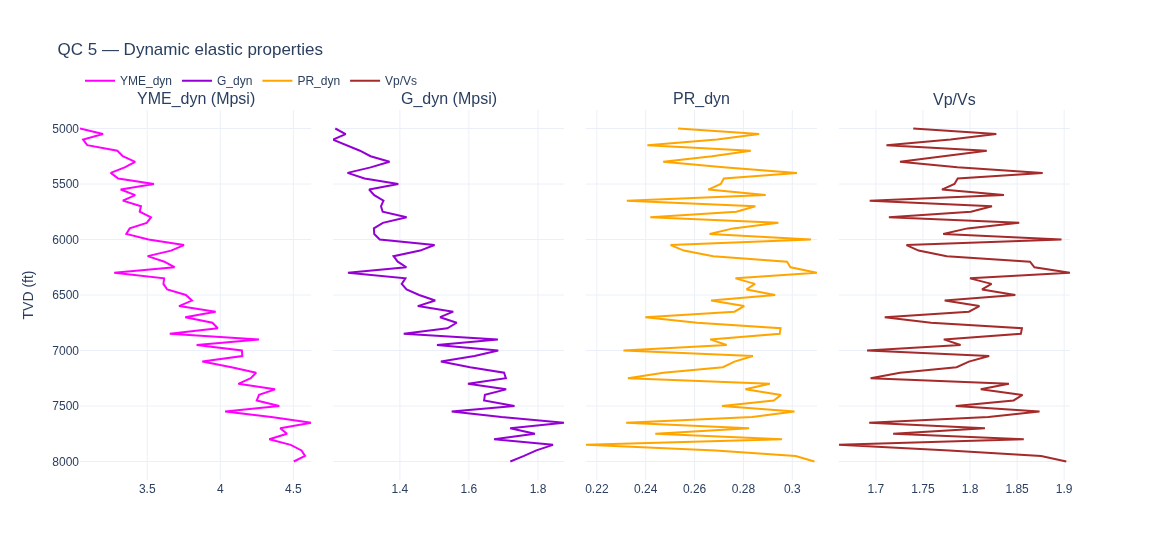

In [6]:
# density must be kg/m3 for the converter
density_kgm3 = (df["RHOB"] * 1000).tolist()

dyn_props = ElasticPropertiesConverter.convert_dynamic_elastic_properties_from_slowness_array(
    p_wave_slowness=df["DTCO"].tolist(),
    s_wave_slowness=df["DTSH"].tolist(),
    density=density_kgm3,
)

df["YME_DYN_Pa"] = [p.youngs_modulus for p in dyn_props]
df["PR_DYN"] = [p.poissons_ratio for p in dyn_props]
df["G_DYN_Pa"] = [p.shear_modulus for p in dyn_props]

# Convert Pa to Mpsi for static correlations that expect Mpsi
PA_TO_MPSI = 1.0 / 6.894757e9
df["YME_DYN_Mpsi"] = df["YME_DYN_Pa"] * PA_TO_MPSI
df["G_DYN_Mpsi"] = df["G_DYN_Pa"] * PA_TO_MPSI
df["VPVS"] = df["DTSH"] / df["DTCO"]
display(df[["TVD", "YME_DYN_Mpsi", "PR_DYN", "G_DYN_Mpsi", "VPVS"]].head())

qc_log_plot(
    [
        ("YME_dyn (Mpsi)", [(df["YME_DYN_Mpsi"], "YME_dyn", "magenta", None)]),
        ("G_dyn (Mpsi)", [(df["G_DYN_Mpsi"], "G_dyn", "darkviolet", None)]),
        ("PR_dyn", [(df["PR_DYN"], "PR_dyn", "orange", None)]),
        ("Vp/Vs", [(df["VPVS"], "Vp/Vs", "brown", None)]),
    ],
    "QC 5 — Dynamic elastic properties",
).show()

## 6. Static elastic properties

Bradford correlation (dynamic to static YME) + simple PR scaling.


,TVD,YME_STA_Mpsi,PR_STA,BIOT
0,5000.0,0.965106,0.253246,1.0
1,5050.0,1.106258,0.286438,1.0
2,5100.0,0.983530,0.269176,1.0
3,5150.0,1.008250,0.240684,1.0
4,5200.0,1.200280,0.283018,1.0


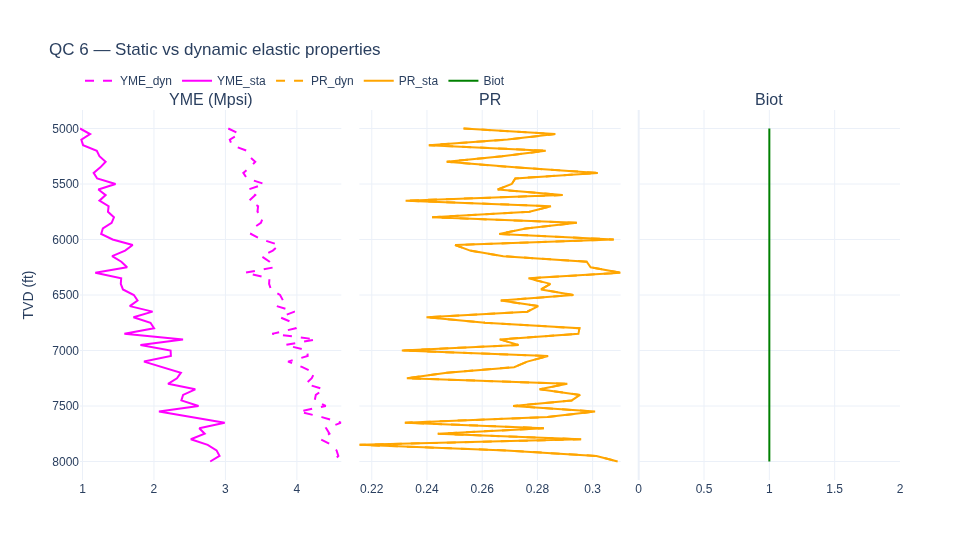

In [7]:
df["YME_STA_Mpsi"] = StaticElasticPropertiesConverter.dyn2sta_yme_bradord_array(
    yme_dyn=df["YME_DYN_Mpsi"].tolist()
)
df["PR_STA"] = StaticElasticPropertiesConverter.dyn2sta_poissons_ratio_array(
    pr_dyn=df["PR_DYN"].tolist(),
    multiplier=1.0,
)
df["BIOT"] = [
    StaticElasticPropertiesConverter.biot_coefficient_constant_law(1.0)
    for _ in range(len(df))
]
display(df[["TVD", "YME_STA_Mpsi", "PR_STA", "BIOT"]].head())

# QC — the dynamic-to-static correction is the single biggest lever in a MEM,
# so plot both curves on the same track to see the magnitude of the shift.
qc_log_plot(
    [
        ("YME (Mpsi)", [(df["YME_DYN_Mpsi"], "YME_dyn", "magenta", "dash"),
                        (df["YME_STA_Mpsi"], "YME_sta", "magenta", None)]),
        ("PR", [(df["PR_DYN"], "PR_dyn", "orange", "dash"),
                (df["PR_STA"], "PR_sta", "orange", None)]),
        ("Biot", [(df["BIOT"], "Biot", "green", None)]),
    ],
    "QC 6 — Static vs dynamic elastic properties",
    width=980,
).show()

## 7. Rock strength (UCS, tensile strength, friction angle)


,TVD,UCS,TSTR,FANG
0,5000.0,0.202968,0.030445,32.220415
1,5050.0,0.232653,0.034898,33.787152
2,5100.0,0.206843,0.031026,32.781899
3,5150.0,0.212042,0.031806,32.005581
4,5200.0,0.252427,0.037864,33.767269


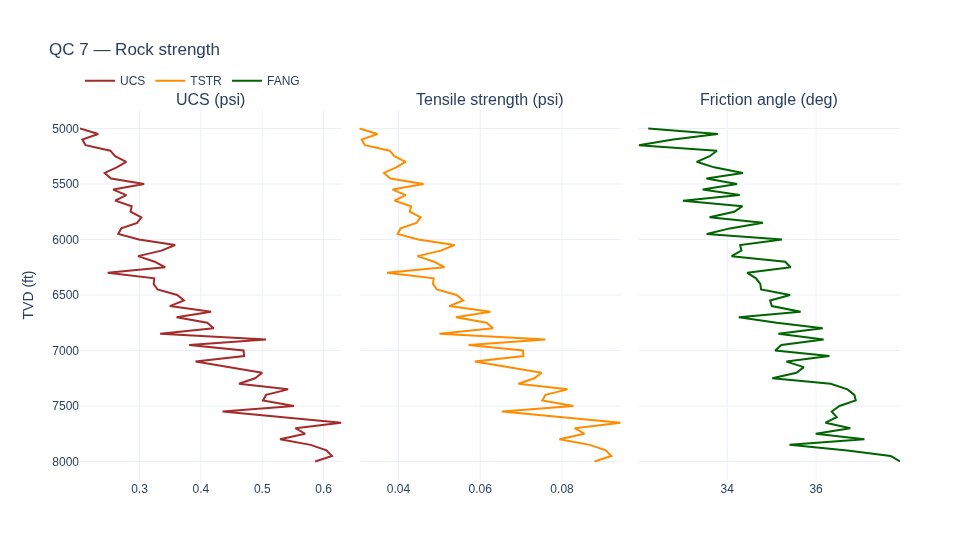

In [8]:
df["UCS"] = RockStrengthPropertiesConverter.convert_yme_sta_to_ucs_plumb_array(
    yme_sta=df["YME_STA_Mpsi"].tolist()
)
df["TSTR"] = RockStrengthPropertiesConverter.convert_ucs_to_tstr_array(
    ucs=df["UCS"].tolist(),
    multiplier=0.15,
)
df["FANG"] = RockStrengthPropertiesConverter.convert_friction_angle_lal_array(
    dtco=df["DTCO"].tolist()
)
display(df[["TVD", "UCS", "TSTR", "FANG"]].head())

qc_log_plot(
    [
        ("UCS (psi)", [(df["UCS"], "UCS", "brown", None)]),
        ("Tensile strength (psi)", [(df["TSTR"], "TSTR", "darkorange", None)]),
        ("Friction angle (deg)", [(df["FANG"], "FANG", "darkgreen", None)]),
    ],
    "QC 7 — Rock strength",
    width=980,
).show()

## 8. Horizontal stresses (poroelastic) + stress-tensor rotation

Poroelastic model gives Shmin / Shmax, then rotate principal stresses into NEV frame.


,TVD,SHMIN,SHMAX,Q_FACTOR,SHMAX_SHMIN_RATIO
0,5000.0,3297.299162,3297.607196,2.999907,1.000093
1,5050.0,3513.453854,3513.797830,2.999902,1.000098
2,5100.0,3450.226000,3450.535974,2.999910,1.000090
3,5150.0,3330.451351,3330.776414,2.999902,1.000098
4,5200.0,3598.231561,3598.605766,2.999896,1.000104


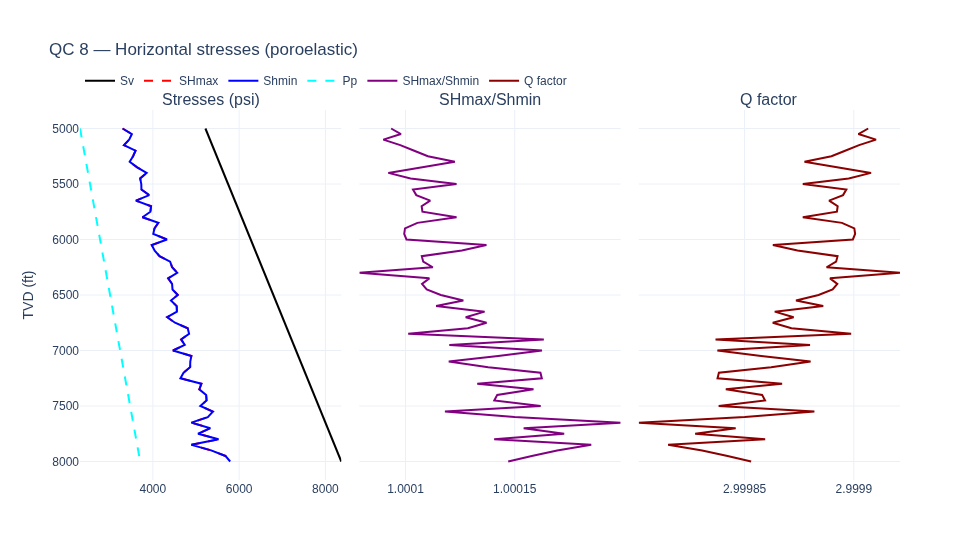

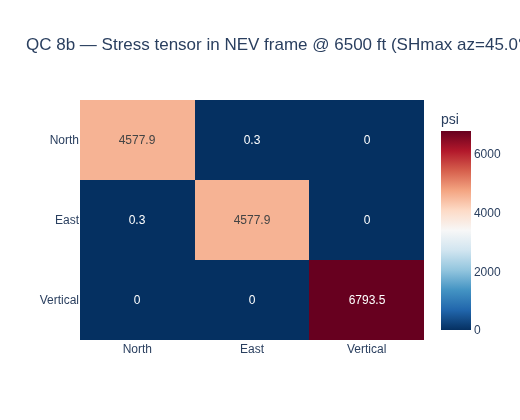

In [9]:
hs_list = HorizontalStressesCalculation.calculate_poroelastic_horizontal_stresses_array(
    overburden_stress=df["SV"].tolist(),
    pore_pressure=df["PP"].tolist(),
    poisson_ratio=df["PR_STA"].tolist(),
    youngs_modulus=df["YME_STA_Mpsi"].tolist(),
    biot_coefficient=df["BIOT"].tolist(),
    EX=0.0001,
    EY=0.0005,
)
df["SHMIN"] = [h.shmin for h in hs_list]
df["SHMAX"] = [h.shmax for h in hs_list]
df["Q_FACTOR"] = [h.q_factor for h in hs_list]
df["SHMAX_SHMIN_RATIO"] = [h.shmax_shmin_ratio for h in hs_list]

# Example rotation at mid-depth
mid = len(df) // 2
SHMAX_AZIMUTH = 45.0  # deg from North
stress_nev = rotate_stress_to_shmax(
    shmin=df["SHMIN"].iloc[mid],
    shmax=df["SHMAX"].iloc[mid],
    svert=df["SV"].iloc[mid],
    shmax_azimuth=SHMAX_AZIMUTH,
)
display(df[["TVD", "SHMIN", "SHMAX", "Q_FACTOR", "SHMAX_SHMIN_RATIO"]].head())

qc_log_plot(
    [
        ("Stresses (psi)", [(df["SV"], "Sv", "black", None),
                            (df["SHMAX"], "SHmax", "red", "dash"),
                            (df["SHMIN"], "Shmin", "blue", None),
                            (df["PP"], "Pp", "cyan", "dash")]),
        ("SHmax/Shmin", [(df["SHMAX_SHMIN_RATIO"], "SHmax/Shmin", "purple", None)]),
        ("Q factor", [(df["Q_FACTOR"], "Q factor", "darkred", None)]),
    ],
    "QC 8 — Horizontal stresses (poroelastic)",
    width=980,
).show()

# QC — the rotated stress tensor in the NEV frame at mid-depth
labels = ["North", "East", "Vertical"]
fig = go.Figure(go.Heatmap(
    z=np.round(stress_nev, 1), x=labels, y=labels, colorscale="RdBu_r",
    text=np.round(stress_nev, 1), texttemplate="%{text}",
    colorbar=dict(title="psi"),
))
fig.update_yaxes(autorange="reversed")
fig.update_layout(
    height=420, width=520, template="plotly_white",
    title=(f"QC 8b — Stress tensor in NEV frame @ {df['TVD'].iloc[mid]:.0f} ft "
           f"(SHmax az={SHMAX_AZIMUTH}°)"),
)
fig.show()

## 9. Wellbore stability (vertical well)

Breakout (Mohr-Coulomb) and breakdown (tensile) pressures.


,TVD,PW_BREAKOUT,PW_BREAKDOWN,PP
0,5000.0,3196.308643,4283.258735,2311.062
1,5050.0,3172.015486,4692.286631,2334.312
2,5100.0,3239.878281,4542.611052,2357.562
3,5150.0,3300.884263,4279.797447,2380.812
4,5200.0,3267.516013,4792.064781,2404.062


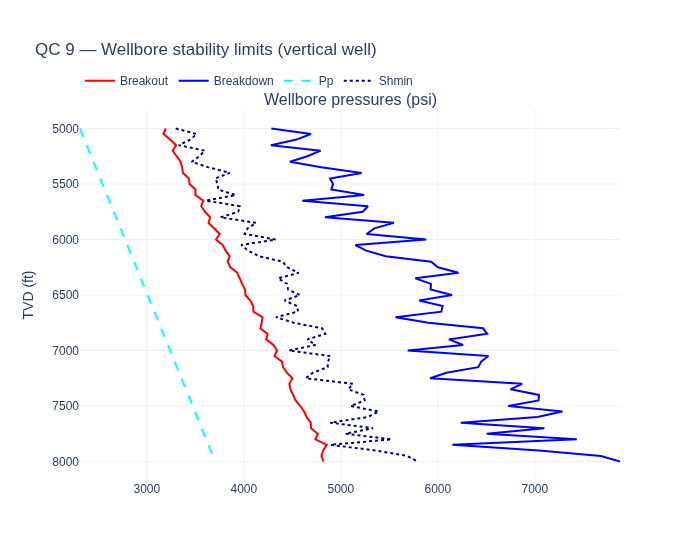

In [10]:
df["PW_BREAKOUT"] = (
    WellboreStabilityCalculation
    .calculate_breakout_calculation_vertical_well_mohr_coulomb_analytical_array(
        shmax=df["SHMAX"].tolist(),
        shmin=df["SHMIN"].tolist(),
        pprs=df["PP"].tolist(),
        overburden_stress=df["SV"].tolist(),
        ucs=df["UCS"].tolist(),
        fang=df["FANG"].tolist(),
        pr_sta=df["PR_STA"].tolist(),
    )
)
df["PW_BREAKDOWN"] = (
    WellboreStabilityCalculation
    .calculate_breakdown_calculation_vertical_well_analytical_array(
        shmax=df["SHMAX"].tolist(),
        shmin=df["SHMIN"].tolist(),
        pprs=df["PP"].tolist(),
        tstr=df["TSTR"].tolist(),
    )
)
display(df[["TVD", "PW_BREAKOUT", "PW_BREAKDOWN", "PP"]].head())

qc_log_plot(
    [
        ("Wellbore pressures (psi)", [(df["PW_BREAKOUT"], "Breakout", "red", None),
                                      (df["PW_BREAKDOWN"], "Breakdown", "blue", None),
                                      (df["PP"], "Pp", "cyan", "dash"),
                                      (df["SHMIN"], "Shmin", "navy", "dot")]),
    ],
    "QC 9 — Wellbore stability limits (vertical well)",
    width=700,
).show()

## 10. Equivalent mud weight (ppg)

Convert the breakout / breakdown pressures into the equivalent static mud weight
a driller would actually dial in, using the classic 0.052 psi/ft-per-ppg factor.

,TVD,MW_PP_PPG,MW_BREAKOUT_PPG,MW_BREAKDOWN_PPG
0,5000.0,8.888700,12.293495,16.474072
1,5050.0,8.889231,12.079267,17.868571
2,5100.0,8.889751,12.216736,17.129001
3,5150.0,8.890261,12.325931,15.981320
4,5200.0,8.890762,12.084009,17.722133


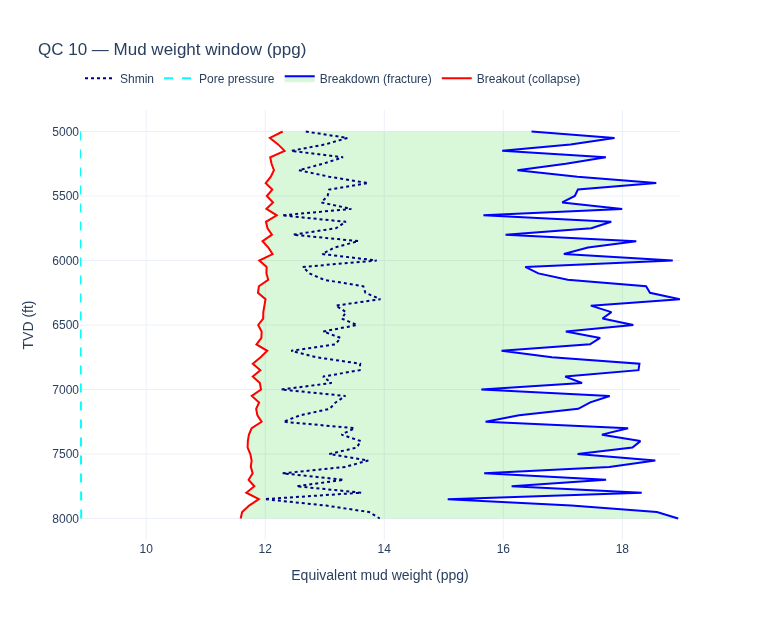

In [11]:
# Equivalent mud weight (ppg) for QC / display, using the classic
# mud-engineering conversion factor of 0.052 psi/ft per ppg.
def pressure_to_mud_weight_ppg(pressure_psi, tvd_ft):
    return np.asarray(pressure_psi) / (0.052 * np.asarray(tvd_ft))


df["MW_BREAKOUT_PPG"] = pressure_to_mud_weight_ppg(df["PW_BREAKOUT"], df["TVD"])
df["MW_BREAKDOWN_PPG"] = pressure_to_mud_weight_ppg(df["PW_BREAKDOWN"], df["TVD"])
df["MW_PP_PPG"] = pressure_to_mud_weight_ppg(df["PP"], df["TVD"])
df["MW_SHMIN_PPG"] = pressure_to_mud_weight_ppg(df["SHMIN"], df["TVD"])
display(df[["TVD", "MW_PP_PPG", "MW_BREAKOUT_PPG", "MW_BREAKDOWN_PPG"]].head())

# QC — the drillable mud weight window, shaded between the collapse (breakout)
# and fracture (breakdown) limits.
fig = go.Figure()
fig.add_trace(go.Scatter(x=df["MW_BREAKOUT_PPG"], y=df["TVD"], mode="lines",
                         line=dict(color="red"), name="Breakout (collapse)"))
fig.add_trace(go.Scatter(x=df["MW_BREAKDOWN_PPG"], y=df["TVD"], mode="lines",
                         line=dict(color="blue"), name="Breakdown (fracture)",
                         fill="tonextx", fillcolor="rgba(0,200,0,0.15)"))
fig.add_trace(go.Scatter(x=df["MW_PP_PPG"], y=df["TVD"], mode="lines",
                         line=dict(color="cyan", dash="dash"), name="Pore pressure"))
fig.add_trace(go.Scatter(x=df["MW_SHMIN_PPG"], y=df["TVD"], mode="lines",
                         line=dict(color="navy", dash="dot"), name="Shmin"))
fig.update_yaxes(autorange="reversed", title_text="TVD (ft)")
fig.update_layout(
    height=620, width=760, template="plotly_white",
    title="QC 10 — Mud weight window (ppg)",
    xaxis_title="Equivalent mud weight (ppg)",
    legend=dict(orientation="h", yanchor="bottom", y=1.04, xanchor="left", x=0),
    margin=dict(t=110),
)
fig.show()

## Summary plot — key MEM curves


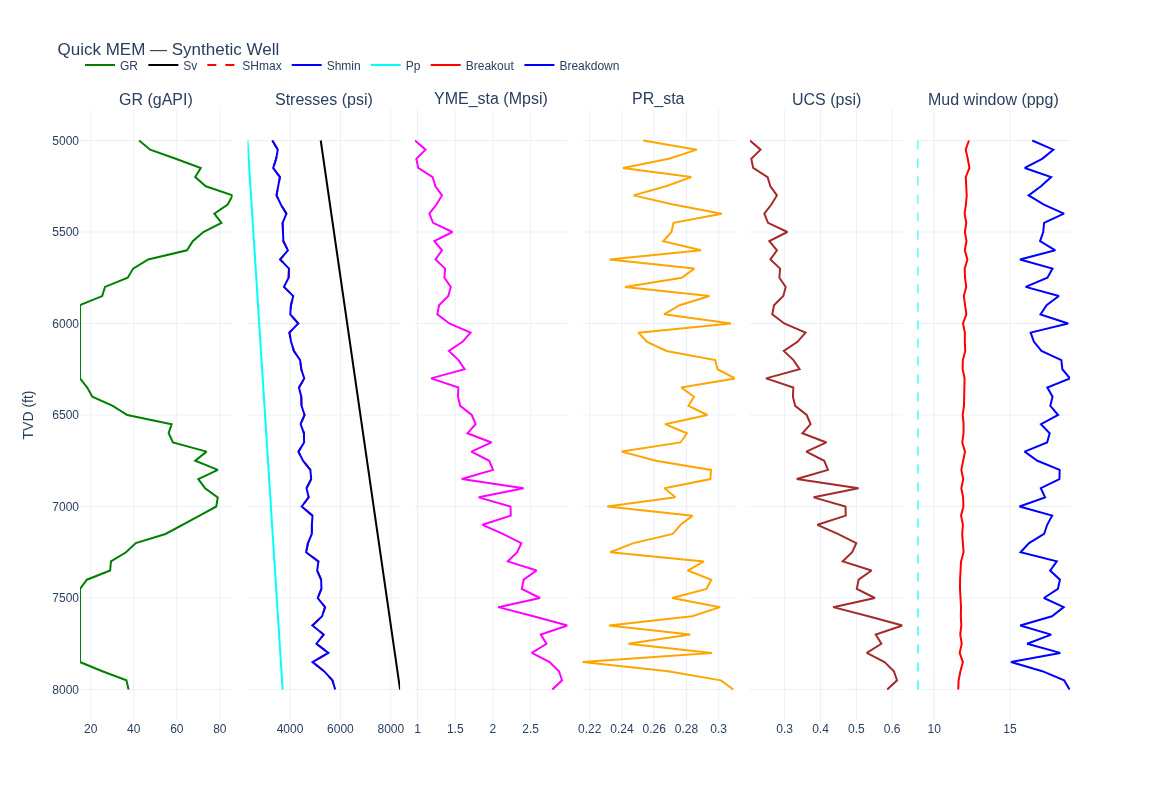

In [12]:
# Interactive 6-track composite log (hover, zoom, pan; depth increases downward)
fig = make_subplots(
    rows=1, cols=6, shared_yaxes=True, horizontal_spacing=0.015,
    subplot_titles=("GR (gAPI)", "Stresses (psi)", "YME_sta (Mpsi)",
                    "PR_sta", "UCS (psi)", "Mud window (ppg)"),
)

# Track 1 - Gamma Ray
fig.add_trace(go.Scatter(x=df["GR"], y=df["TVD"], mode="lines",
                         line=dict(color="green"), name="GR"), row=1, col=1)

# Track 2 - stress profiles (psi)
for col, color, dash, name in [("SV", "black", None, "Sv"),
                               ("SHMAX", "red", "dash", "SHmax"),
                               ("SHMIN", "blue", None, "Shmin"),
                               ("PP", "cyan", None, "Pp")]:
    fig.add_trace(go.Scatter(x=df[col], y=df["TVD"], mode="lines",
                             line=dict(color=color, dash=dash), name=name), row=1, col=2)

# Track 3 - static Young's modulus
fig.add_trace(go.Scatter(x=df["YME_STA_Mpsi"], y=df["TVD"], mode="lines",
                         line=dict(color="magenta"), name="YME_sta",
                         showlegend=False), row=1, col=3)

# Track 4 - static Poisson's ratio
fig.add_trace(go.Scatter(x=df["PR_STA"], y=df["TVD"], mode="lines",
                         line=dict(color="orange"), name="PR_sta",
                         showlegend=False), row=1, col=4)

# Track 5 - UCS (psi; note the geomechpy Plumb correlation returns small values)
fig.add_trace(go.Scatter(x=df["UCS"], y=df["TVD"], mode="lines",
                         line=dict(color="brown"), name="UCS",
                         showlegend=False), row=1, col=5)

# Track 6 - mud window (ppg equivalent mud weight)
for col, color, dash, name, show in [
    ("MW_BREAKOUT_PPG", "red", None, "Breakout", True),
    ("MW_BREAKDOWN_PPG", "blue", None, "Breakdown", True),
    ("MW_PP_PPG", "cyan", "dash", "Pp", False),
]:
    fig.add_trace(go.Scatter(x=df[col], y=df["TVD"], mode="lines",
                             line=dict(color=color, dash=dash), name=name,
                             showlegend=show), row=1, col=6)

fig.update_yaxes(autorange="reversed", title_text="TVD (ft)", row=1, col=1)
fig.update_layout(
    height=800, width=1150, template="plotly_white",
    title="Quick MEM — Synthetic Well",
    legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="left", x=0),
    margin=dict(t=110),
)
fig.show()

## Done

The DataFrame `df` now holds a complete 1-D MEM at every depth sample, and every
computation stage above carries its own QC plot so the model can be inspected
step by step rather than only at the end.

Stresses are reported in **psi**; the mud weight window is reported in **ppg**.

Export with:

```python
df.to_csv("quick_mem_results.csv", index=False)
```